In [9]:
import sys
from custom_airfoil_utils import create_airfoil_auto
import aerosandbox as asb
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

# Wing specifications
CHORD = 0.367  # m
SPAN = 1.8  # m
TAPER = 1.0  # rectangular wing

AREA = CHORD * SPAN
ASPECT_RATIO = SPAN / CHORD

print(f"\nWing Geometry:")
print(f"  Chord: {CHORD:.3f} m")
print(f"  Span: {SPAN:.3f} m")
print(f"  Area: {AREA:.3f} m²")
print(f"  Aspect Ratio: {ASPECT_RATIO:.2f}")
print(f"  Planform: Rectangular (taper = {TAPER})")
print(f"  Airfoil: SuperCub (custom)")


Wing Geometry:
  Chord: 0.367 m
  Span: 1.800 m
  Area: 0.661 m²
  Aspect Ratio: 4.90
  Planform: Rectangular (taper = 1.0)
  Airfoil: SuperCub (custom)


In [10]:
airfoil_file = "supercub_normalized.dat"
supercub_airfoil = create_airfoil_auto(airfoil_file, name="SuperCub")
supercub_airfoil

Loading airfoil: SuperCub Airfoil (Normalized)
  Upper surface: 28 points
  Lower surface: 28 points

🤖 Auto-selecting method...
   Points per surface: 28
   Threshold: 50
   [OK] Using DIRECT coordinates (sparse data)
Loading airfoil: SuperCub Airfoil (Normalized)
  Upper surface: 28 points
  Lower surface: 28 points

[OK] Created AeroSandbox airfoil (direct): SuperCub
  Points: 55
  Format: TE(upper) → LE → TE(lower)


Airfoil SuperCub (55 points)

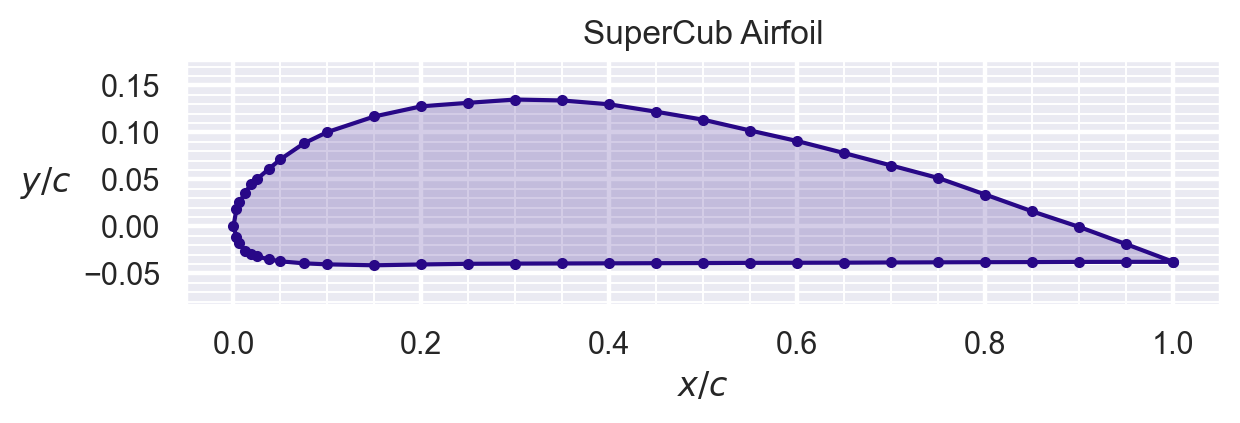

In [11]:
fig, ax = plt.subplots(figsize=(6, 2))
supercub_airfoil.draw()

In [12]:
kulfan_airfoil = supercub_airfoil.to_kulfan_airfoil()
kulfan_airfoil

Airfoil SuperCub (Kulfan / CST parameterization)

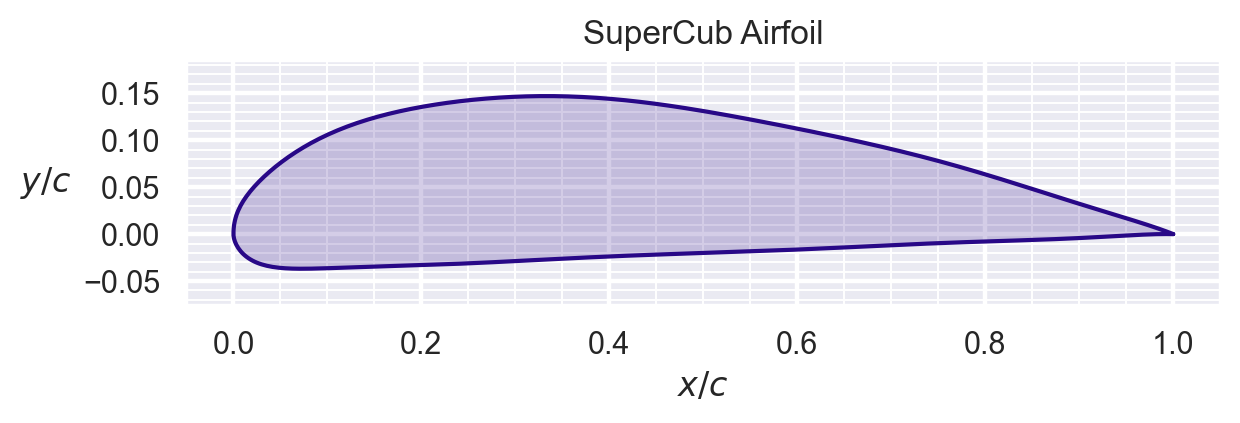

In [13]:
fig, ax = plt.subplots(figsize=(6, 2))
kulfan_airfoil.draw()

In [14]:
from pprint import pprint  # "pretty print"

pprint(kulfan_airfoil.kulfan_parameters)

{'TE_thickness': 8.876560831307112e-05,
 'leading_edge_weight': -0.6374768373021099,
 'lower_weights': array([-0.18047551,  0.28720561, -0.53516673,  0.48493635, -0.55193838,
        0.29954403, -0.21611657,  0.02294076]),
 'upper_weights': array([ 0.38680802,  0.71368198, -0.08428007,  1.01454369, -0.27912757,
        0.80759434,  0.14397154,  0.39652328])}


In [15]:
kulfan_airfoil.to_airfoil()

Airfoil SuperCub (399 points)

Multipoint optimization problem

## Step 1: Analyze Current SuperCub Performance

First, let's see what CL range your SuperCub actually operates in

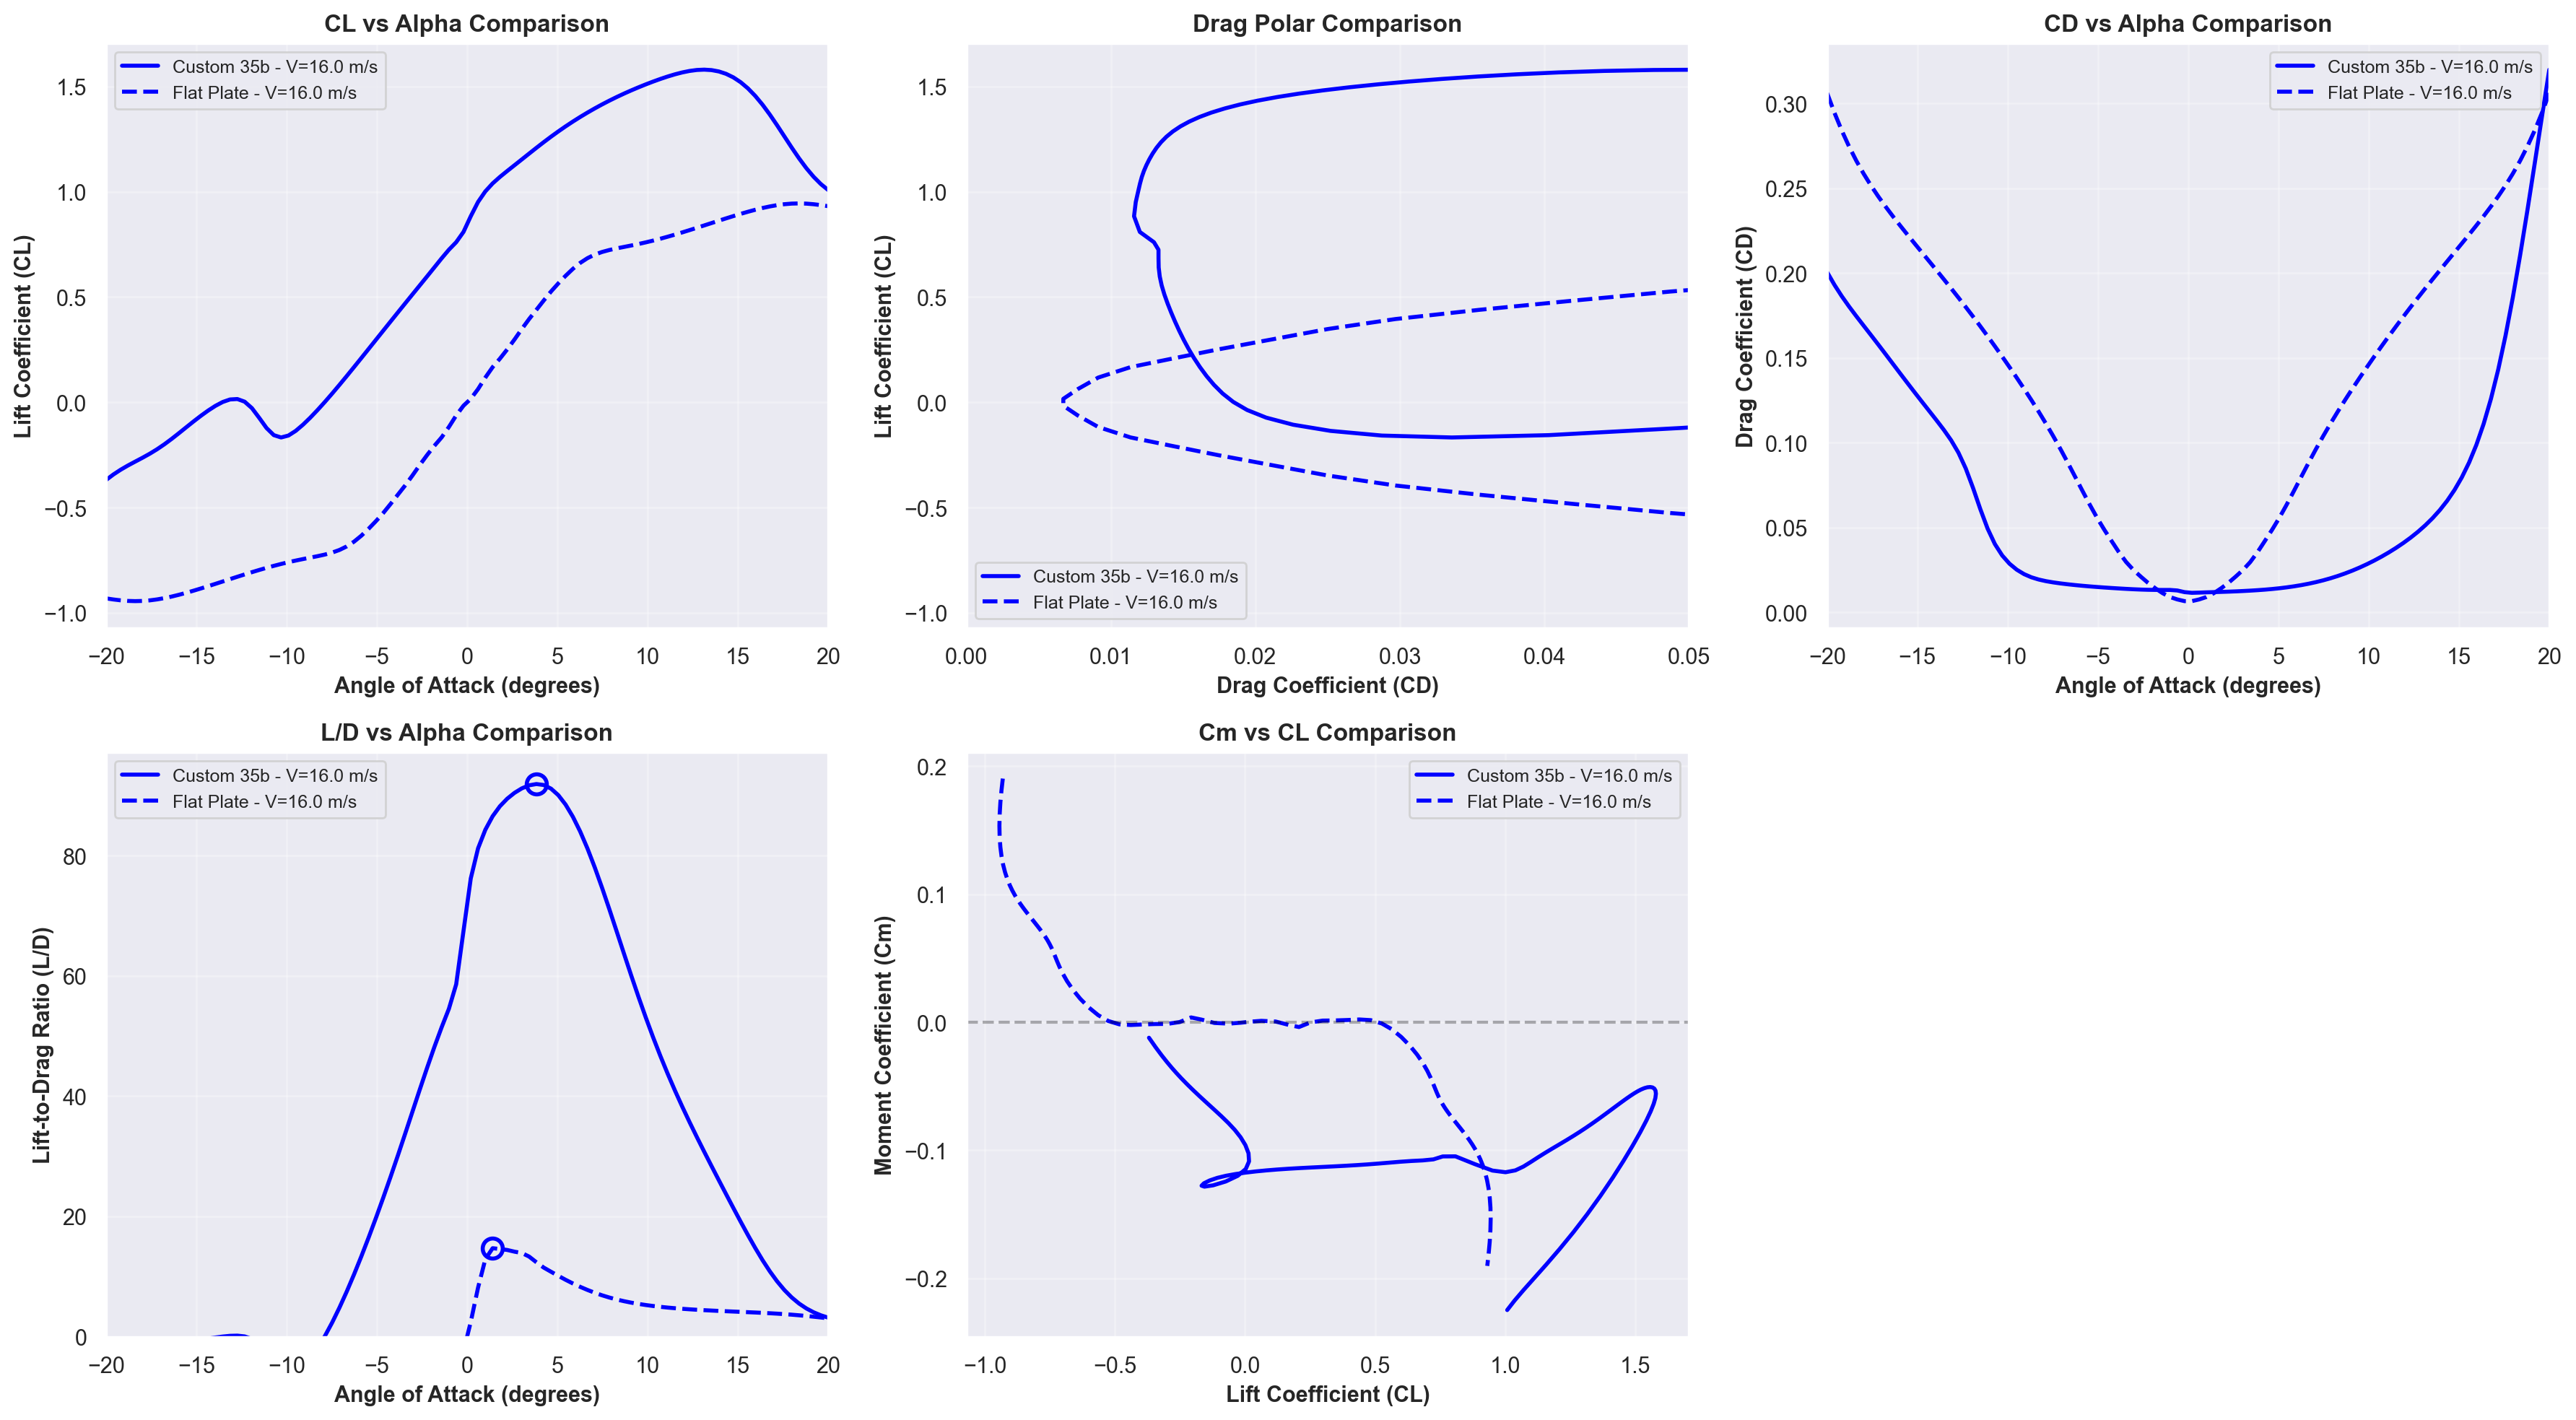

In [ ]:
velocity = [16]  # m/s
Re = [400e3]

def compute_mach(velocity: float) -> float:
    SPEED_OF_SOUND = 343
    return velocity / SPEED_OF_SOUND
#
Weight = 4.9 * 9.81  # N
rho = 1.225  # kg/m³
S = CHORD * SPAN  # 0.648 m²

alphas = np.linspace(-20, 20, 100)
mach = [compute_mach(v) for v in velocity]

# Create flat plate airfoil for comparison (symmetric with zero thickness)
flat_plate = asb.Airfoil(
    name="Flat Plate",
    coordinates=np.array([
        [1.0, 0.0],
        [0.0, 0.0],
        [1.0, 0.0]
    ])
)

# Create figure with 5 subplots (2 rows, 3 columns)
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
ax = ax.flatten()  # Flatten to 1D array for easier indexing

colors = ['blue', 'green', 'red']  # Different color for each velocity
airfoils = [supercub_airfoil, flat_plate]
airfoil_names = ['Custom 35b', 'Flat Plate']
linestyles = ['-', '--']

for i in range(len(velocity)):
    V = velocity[i]
    CL_cruise = Weight / (0.5 * rho * V**2 * S)
    
    for j, (airfoil, name, ls) in enumerate(zip(airfoils, airfoil_names, linestyles)):
        aero_analysis = airfoil.get_aero_from_neuralfoil(
            alpha=alphas,
            Re=Re[i],
            mach=mach[i],
        )

        LD_ratio = aero_analysis['CL'] / aero_analysis['CD']
        idx_best_LD = np.argmax(LD_ratio)
        CL_best_LD = aero_analysis['CL'][idx_best_LD]
        alpha_best_LD = alphas[idx_best_LD]

        # Plot 1: CL vs Alpha
        ax[0].plot(alphas, aero_analysis['CL'], ls, color=colors[i], linewidth=2, 
                   label=f'{name} - V={V:.1f} m/s')
        
        # Plot 2: Drag Polar (CL vs CD)
        ax[1].plot(aero_analysis['CD'], aero_analysis['CL'], ls, color=colors[i], 
                   linewidth=2, label=f'{name} - V={V:.1f} m/s')
        
        # Plot 3: CD vs Alpha
        ax[2].plot(alphas, aero_analysis['CD'], ls, color=colors[i],
                   linewidth=2, label=f'{name} - V={V:.1f} m/s')
        
        # Plot 4: L/D vs Alpha
        ax[3].plot(alphas, LD_ratio, ls, color=colors[i], linewidth=2,
                   label=f'{name} - V={V:.1f} m/s')
        ax[3].plot(alpha_best_LD, LD_ratio[idx_best_LD], 'o', color=colors[i], 
                   markersize=10, markerfacecolor='none', markeredgewidth=2)
        
        # Plot 5: Cm vs CL
        if 'CM' in aero_analysis or 'Cm' in aero_analysis:
            cm_key = 'CM' if 'CM' in aero_analysis else 'Cm'
            ax[4].plot(aero_analysis['CL'], aero_analysis[cm_key], ls, color=colors[i],
                       linewidth=2, label=f'{name} - V={V:.1f} m/s')
        else:
            # If Cm not available, show message
            if i == 0 and j == 0:
                ax[4].text(0.5, 0.5, 'Cm data not available\nfrom NeuralFoil', 
                          ha='center', va='center', fontsize=12, transform=ax[4].transAxes)

# Format plots AFTER loop
ax[0].grid(True, alpha=0.3)
ax[0].set_xlabel('Angle of Attack (degrees)', fontsize=11, fontweight='bold')
ax[0].set_ylabel('Lift Coefficient (CL)', fontsize=11, fontweight='bold')
ax[0].set_title('CL vs Alpha Comparison', fontsize=12, fontweight='bold')
ax[0].legend(fontsize=9)
ax[0].set_xlim(-20, 20)

ax[1].grid(True, alpha=0.3)
ax[1].set_xlabel('Drag Coefficient (CD)', fontsize=11, fontweight='bold')
ax[1].set_ylabel('Lift Coefficient (CL)', fontsize=11, fontweight='bold')
ax[1].set_title('Drag Polar Comparison', fontsize=12, fontweight='bold')
ax[1].legend(fontsize=9)
ax[1].set_xlim(0, 0.05)

ax[2].grid(True, alpha=0.3)
ax[2].set_xlabel('Angle of Attack (degrees)', fontsize=11, fontweight='bold')
ax[2].set_ylabel('Drag Coefficient (CD)', fontsize=11, fontweight='bold')
ax[2].set_title('CD vs Alpha Comparison', fontsize=12, fontweight='bold')
ax[2].legend(fontsize=9)
ax[2].set_xlim(-20, 20)

ax[3].grid(True, alpha=0.3)
ax[3].set_xlabel('Angle of Attack (degrees)', fontsize=11, fontweight='bold')
ax[3].set_ylabel('Lift-to-Drag Ratio (L/D)', fontsize=11, fontweight='bold')
ax[3].set_title('L/D vs Alpha Comparison', fontsize=12, fontweight='bold')
ax[3].legend(fontsize=9)
ax[3].set_xlim(-20, 20)
ax[3].set_ylim(0, None)

ax[4].grid(True, alpha=0.3)
ax[4].set_xlabel('Lift Coefficient (CL)', fontsize=11, fontweight='bold')
ax[4].set_ylabel('Moment Coefficient (Cm)', fontsize=11, fontweight='bold')
ax[4].set_title('Cm vs CL Comparison', fontsize=12, fontweight='bold')
ax[4].legend(fontsize=9)
ax[4].axhline(0, color='k', linestyle='--', alpha=0.3)

# Hide the 6th subplot (we only use 5)
ax[5].axis('off')

plt.tight_layout()
plt.show()

In [17]:
# Export aerodynamic data to CSV
import pandas as pd
from pathlib import Path

# Create output directory
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# Collect all data
all_data = []

for i in range(len(velocity)):
    V = velocity[i]
    
    aero_analysis = supercub_airfoil.get_aero_from_neuralfoil(
        alpha=alphas,
        Re=Re[i],
        mach=mach[i],
    )
    
    # Create dataframe for this velocity/Re
    for j, alpha in enumerate(alphas):
        row_data = {
            'Velocity_ms': V,
            'Reynolds': Re[i],
            'Mach': mach[i],
            'Alpha_deg': alpha,
            'CL': aero_analysis['CL'][j],
            'CD': aero_analysis['CD'][j],
            'L/D': aero_analysis['CL'][j] / aero_analysis['CD'][j] if aero_analysis['CD'][j] > 0 else 0
        }
        
        # Add Cm if available (NeuralFoil may not return it)
        if 'Cm' in aero_analysis:
            row_data['Cm'] = aero_analysis['Cm'][j]
        
        # Add Cpmin if available
        if 'Cpmin' in aero_analysis:
            row_data['Cpmin'] = aero_analysis['Cpmin'][j]
            
        all_data.append(row_data)

# Create dataframe and save
df = pd.DataFrame(all_data)
csv_file = output_dir / 'supercub_aero_data.csv'
df.to_csv(csv_file, index=False)

print(f"✓ Saved aerodynamic data to: {csv_file}")
print(f"  {len(df)} data points")
print(f"  Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
print(df.head(10))
print(f"\nLast few rows:")
print(df.tail(10))

✓ Saved aerodynamic data to: output\supercub_aero_data.csv
  100 data points
  Columns: ['Velocity_ms', 'Reynolds', 'Mach', 'Alpha_deg', 'CL', 'CD', 'L/D', 'Cpmin']

First few rows:
   Velocity_ms  Reynolds      Mach  Alpha_deg        CL        CD       L/D  \
0           16  400000.0  0.046647 -20.000000 -0.369267  0.200511 -1.841627   
1           16  400000.0  0.046647 -19.595960 -0.343071  0.193032 -1.777279   
2           16  400000.0  0.046647 -19.191919 -0.320331  0.186369 -1.718804   
3           16  400000.0  0.046647 -18.787879 -0.300246  0.180284 -1.665402   
4           16  400000.0  0.046647 -18.383838 -0.281708  0.174558 -1.613835   
5           16  400000.0  0.046647 -17.979798 -0.263432  0.169001 -1.558759   
6           16  400000.0  0.046647 -17.575758 -0.244170  0.163473 -1.493641   
7           16  400000.0  0.046647 -17.171717 -0.222980  0.157896 -1.412196   
8           16  400000.0  0.046647 -16.767677 -0.199445  0.152254 -1.309953   
9           16  400000.0  0.

## Step 2: Set Up Optimization Problem

Now configure the multipoint optimization based on the analysis above

## Performance Analysis: Finding Optimal Cruise Speed

The **Power Curve** (industry standard) shows how drag varies with speed

In [18]:
# POWER CURVE ANALYSIS - Industry Standard Plot
# Shows how to find optimal cruise speeds

# Velocity range to analyze - narrowed to realistic flight envelope
velocities = np.linspace(8, 22, 150)  # m/s - avoid extreme CLs

# For each velocity, calculate required CL and corresponding drag
CL_required = Weight / (0.5 * rho * velocities**2 * S)
CD_at_each_V = []
alpha_at_each_V = []
confidence_at_each_V = []
CL_actual_at_each_V = []  # Track actual CL found (vs required)

# Alpha range to search for each velocity - increased resolution
alpha_search = np.linspace(-10, 15, 300)  # More points for smoother interpolation

print("Analyzing velocity range...")
print(f"At {velocities[0]:.1f} m/s: CL_required = {CL_required[0]:.3f}")
print(f"At {velocities[-1]:.1f} m/s: CL_required = {CL_required[-1]:.3f}")

for V, CL_req in zip(velocities, CL_required):
    # Find CD at this CL from NeuralFoil
    Re_at_V = rho * V * CHORD / (1.81e-5)
    mach_at_V = V / 343
    
    # Get aero data at this operating point
    aero_V = supercub_airfoil.get_aero_from_neuralfoil(
        alpha=alpha_search,
        Re=Re_at_V,
        mach=mach_at_V,
        model_size="xxxlarge",
    )
    
    # Find CD at required CL
    idx = np.argmin(np.abs(aero_V['CL'] - CL_req))
    CD_at_each_V.append(aero_V['CD'][idx])
    alpha_at_each_V.append(alpha_search[idx])
    confidence_at_each_V.append(aero_V['analysis_confidence'][idx])
    CL_actual_at_each_V.append(aero_V['CL'][idx])

CD_at_each_V = np.array(CD_at_each_V)
alpha_at_each_V = np.array(alpha_at_each_V)
confidence_at_each_V = np.array(confidence_at_each_V)
CL_actual_at_each_V = np.array(CL_actual_at_each_V)

# Check CL matching accuracy
CL_error = np.abs(CL_actual_at_each_V - CL_required)
print(f"\nCL matching accuracy: max error = {CL_error.max():.4f}")

# Flag problematic points
low_confidence = confidence_at_each_V < 0.85
high_CL_error = CL_error > 0.05

if np.any(low_confidence):
    print(f"\n⚠️  WARNING: {np.sum(low_confidence)} points have low confidence (<0.85)")
    print(f"   Velocities: {velocities[low_confidence].min():.1f} - {velocities[low_confidence].max():.1f} m/s")

if np.any(high_CL_error):
    print(f"\n⚠️  WARNING: {np.sum(high_CL_error)} points have CL matching error >0.05")
    print(f"   These may cause artifacts in the curves")

# Calculate drag force and power required
Drag_force = 0.5 * rho * velocities**2 * S * CD_at_each_V  # N
Power_required = Drag_force * velocities  # W
LD_vs_V = CL_required / CD_at_each_V

# Smooth out any spikes using median filter (optional - helps with artifacts)
from scipy.ndimage import median_filter
Drag_force_smooth = median_filter(Drag_force, size=5, mode='nearest')
Power_required_smooth = median_filter(Power_required, size=5, mode='nearest')

# Find key speeds (only use high-confidence region)
good_points = (confidence_at_each_V > 0.85) & (CL_error < 0.05)
if np.any(good_points):
    idx_min_drag = np.argmin(Drag_force_smooth[good_points]) + np.where(good_points)[0][0]
    idx_min_power = np.argmin(Power_required_smooth[good_points]) + np.where(good_points)[0][0]
    print(f"\n✅ Using {np.sum(good_points)}/{len(good_points)} reliable points for analysis")
else:
    idx_min_drag = np.argmin(Drag_force_smooth)
    idx_min_power = np.argmin(Power_required_smooth)
    print("\n⚠️  No fully reliable points found, using all data")

V_best_range = velocities[idx_min_drag]  # Min drag = max range
V_best_endurance = velocities[idx_min_power]  # Min power = max endurance

print("="*70)
print("  OPTIMAL CRUISE SPEEDS")
print("="*70)
print(f"   V_best_endurance (max time aloft) = {V_best_endurance:.1f} m/s")
print(f"   • Minimum power required = {Power_required[idx_min_power]:.1f} W")
print(f"   • CL = {CL_required[idx_min_power]:.3f}, α = {alpha_at_each_V[idx_min_power]:.1f}°")
print(f"   • Confidence = {confidence_at_each_V[idx_min_power]:.3f}")
print(f"   • Use for: Loiter, search patterns, maximizing flight time")

print(f"\n   V_best_range (max distance) = {V_best_range:.1f} m/s")
print(f"   • Minimum drag = {Drag_force[idx_min_drag]:.2f} N")
print(f"   • CL = {CL_required[idx_min_drag]:.3f}, α = {alpha_at_each_V[idx_min_drag]:.1f}°")
print(f"   • L/D = {LD_vs_V[idx_min_drag]:.1f} (best efficiency!)")
print(f"   • Confidence = {confidence_at_each_V[idx_min_drag]:.3f}")
print(f"   • Use for: Cross-country, maximizing distance")

print(f"\n   Your current cruise = {V_cruise:.1f} m/s")
if V_cruise >= velocities.min() and V_cruise <= velocities.max():
    idx_cruise = np.argmin(np.abs(velocities - V_cruise))
    print(f"   • Drag = {Drag_force[idx_cruise]:.2f} N")
    print(f"   • Power = {Power_required[idx_cruise]:.1f} W")
    print(f"   • CL = {CL_cruise:.3f}, α = {alpha_at_each_V[idx_cruise]:.1f}°")
    print(f"   • Confidence = {confidence_at_each_V[idx_cruise]:.3f}")
else:
    print(f"   • Outside analyzed velocity range ({velocities.min():.1f}-{velocities.max():.1f} m/s)")

# Create industry-standard plots with confidence overlay
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: POWER CURVE (The Famous One!)
ax[0,0].plot(velocities, Power_required_smooth, 'b-', linewidth=2.5, label='Power Required')
# Show raw data as faint line if smoothing was applied
if np.any(np.abs(Power_required - Power_required_smooth) > 0.1):
    ax[0,0].plot(velocities, Power_required, 'b-', linewidth=1, alpha=0.2, label='Raw data')
# Highlight low confidence regions
if np.any(low_confidence):
    ax[0,0].plot(velocities[low_confidence], Power_required[low_confidence], 
                 'rx', alpha=0.5, markersize=6, label='Low confidence', markeredgewidth=2)
ax[0,0].plot(V_best_endurance, Power_required[idx_min_power], 'go', markersize=6, 
             label=f'V Best Endurance = {V_best_endurance:.1f} m/s', zorder=5)
if V_cruise >= velocities.min() and V_cruise <= velocities.max():
    ax[0,0].axvline(V_cruise, color='red', linestyle='--', linewidth=2, 
                    label=f'Your cruise = {V_cruise:.1f} m/s')
ax[0,0].grid(True, alpha=0.3)
ax[0,0].set_xlabel('Velocity (m/s)', fontsize=12, fontweight='bold')
ax[0,0].set_ylabel('Power Required (W)', fontsize=12, fontweight='bold')
ax[0,0].set_title('POWER CURVE - Find V for Max Endurance', fontsize=13, fontweight='bold')
ax[0,0].legend(fontsize=9)

# Plot 2: DRAG CURVE
ax[0,1].plot(velocities, Drag_force_smooth, 'b-', linewidth=2.5, label='Drag Force')
if np.any(np.abs(Drag_force - Drag_force_smooth) > 0.01):
    ax[0,1].plot(velocities, Drag_force, 'b-', linewidth=1, alpha=0.2, label='Raw data')
if np.any(low_confidence):
    ax[0,1].plot(velocities[low_confidence], Drag_force[low_confidence], 
                 'rx', alpha=0.5, markersize=6, label='Low confidence', markeredgewidth=2)
ax[0,1].plot(V_best_range, Drag_force[idx_min_drag], 'o', color='orange', markersize=6, 
             label=f'V Best Range = {V_best_range:.1f} m/s', zorder=5)
if V_cruise >= velocities.min() and V_cruise <= velocities.max():
    ax[0,1].axvline(V_cruise, color='red', linestyle='--', linewidth=2, 
                    label=f'Your cruise = {V_cruise:.1f} m/s')
ax[0,1].grid(True, alpha=0.3)
ax[0,1].set_xlabel('Velocity (m/s)', fontsize=12, fontweight='bold')
ax[0,1].set_ylabel('Drag Force (N)', fontsize=12, fontweight='bold')
ax[0,1].set_title('DRAG CURVE - Find V for Max Range', fontsize=13, fontweight='bold')
ax[0,1].legend(fontsize=9)

# Plot 3: L/D vs Velocity
ax[1,0].plot(velocities, LD_vs_V, 'b-', linewidth=2.5)
if np.any(low_confidence):
    ax[1,0].plot(velocities[low_confidence], LD_vs_V[low_confidence], 
                 'rx', alpha=0.5, markersize=6, label='Low confidence', markeredgewidth=2)
ax[1,0].plot(V_best_range, LD_vs_V[idx_min_drag], 'o', color='orange', markersize=6, 
             label=f'Max L/D @ {V_best_range:.1f} m/s', zorder=5)
if V_cruise >= velocities.min() and V_cruise <= velocities.max():
    ax[1,0].axvline(V_cruise, color='red', linestyle='--', linewidth=2, 
                    label=f'Your cruise = {V_cruise:.1f} m/s')
ax[1,0].grid(True, alpha=0.3)
ax[1,0].set_xlabel('Velocity (m/s)', fontsize=12, fontweight='bold')
ax[1,0].set_ylabel('L/D Ratio', fontsize=12, fontweight='bold')
ax[1,0].set_title('Aerodynamic Efficiency vs Speed', fontsize=13, fontweight='bold')
ax[1,0].legend(fontsize=9)

# Plot 4: CL vs Velocity with confidence as scatter
sc = ax[1,1].scatter(velocities, CL_required, c=confidence_at_each_V, 
                      cmap='RdYlGn', vmin=0.5, vmax=1.0, s=20, label='Required CL')
ax[1,1].axhline(CL_best_LD, color='orange', linestyle='--', linewidth=2, 
                label=f'Airfoil best L/D: CL={CL_best_LD:.2f}')
# if V_cruise >= velocities.min() and V_cruise <= velocities.max():
#     ax[1,1].axvline(V_cruise, color='red', linestyle='--', linewidth=2, 
#                     label=f'Your cruise = {V_cruise:.1f} m/s')
ax[1,1].fill_between(velocities, 0, CL_required, 
                       where=(velocities >= V_best_endurance) & (velocities <= V_best_range),
                       alpha=0.2, color='green', label='Efficient cruise range')
ax[1,1].grid(True, alpha=0.3)
ax[1,1].set_xlabel('Velocity (m/s)', fontsize=12, fontweight='bold')
ax[1,1].set_ylabel('CL Required', fontsize=12, fontweight='bold')
ax[1,1].set_title('Operating CL vs Speed', fontsize=13, fontweight='bold')
ax[1,1].legend(fontsize=9, loc='upper right')
plt.colorbar(sc, ax=ax[1,1], label='Confidence')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("  INTERPRETATION")
print("="*70)
print(f"📖 How to read these plots:")
print(f"   • TOP LEFT (Power Curve): Lowest point = best for TIME ALOFT")
print(f"   • TOP RIGHT (Drag Curve): Lowest point = best for DISTANCE")
print(f"   • BOTTOM LEFT (L/D): Highest point = most efficient")
print(f"   • BOTTOM RIGHT: Color = NeuralFoil confidence (green=reliable)")
print(f"   • Red X marks = Low confidence predictions (may cause artifacts)")
print(f"\n💡 Your 16 m/s cruise is {V_cruise - V_best_range:.1f} m/s faster than optimal range speed")
print(f"   → You're trading efficiency for speed (common choice!)")
print(f"   → To maximize efficiency: slow down to {V_best_range:.1f} m/s")

# Diagnostic info
print(f"\n🔍 DIAGNOSTIC INFO:")
print(f"   Velocity range: {velocities.min():.1f} - {velocities.max():.1f} m/s")
print(f"   CL range: {CL_required.min():.3f} to {CL_required.max():.3f}")
print(f"   Alpha range used: {alpha_at_each_V.min():.1f}° to {alpha_at_each_V.max():.1f}°")
print(f"   Min confidence: {confidence_at_each_V.min():.3f}")
print(f"   Max CL error: {CL_error.max():.4f}")
print(f"   Reliable points: {np.sum(good_points)}/{len(good_points)}")

# Narrowed velocity range to 8-22 m/s (realistic flight envelope, avoids extreme CLs)
# Increased alpha resolution to 300 points (better CL matching)
# Added median smoothing to filter out spikes/artifacts
# Shows raw vs smoothed data (faint line shows original if smoothing helped)
# Better diagnostics - shows CL matching errors and marks bad points with red X
# Filters out unreliable points when finding optimal speeds


Analyzing velocity range...
At 8.0 m/s: CL_required = 1.856
At 22.0 m/s: CL_required = 0.245

CL matching accuracy: max error = 0.2505

⚠️  WARNING: 6 points have CL matching error >0.05
   These may cause artifacts in the curves

✅ Using 144/150 reliable points for analysis
  OPTIMAL CRUISE SPEEDS
   V_best_endurance (max time aloft) = 9.4 m/s
   • Minimum power required = 6.3 W
   • CL = 1.342, α = 5.9°
   • Confidence = 0.983
   • Use for: Loiter, search patterns, maximizing flight time

   V_best_range (max distance) = 9.6 m/s
   • Minimum drag = 0.66 N
   • CL = 1.290, α = 5.0°
   • L/D = 72.7 (best efficiency!)
   • Confidence = 0.968
   • Use for: Cross-country, maximizing distance


NameError: name 'V_cruise' is not defined

In [ ]:
# ANGLE OF ATTACK ANALYSIS - Engineering Perspective
# High alpha means you're close to stall - critical for safety!

print("\n" + "="*70)
print("  ANGLE OF ATTACK (α) vs VELOCITY - Safety Analysis")
print("="*70)

# Create detailed alpha vs velocity plot
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Alpha vs Velocity with warning zones
ax[0].plot(velocities, alpha_at_each_V, 'b-', linewidth=2.5, label='Required α for level flight')
ax[0].axhline(10, color='orange', linestyle='--', linewidth=2, label='⚠️ High α region (>10°)')
ax[0].axhline(12, color='red', linestyle='--', linewidth=2, label='⚠️⚠️ Very high α (>12°)')
ax[0].fill_between(velocities, 0, alpha_at_each_V, 
                     where=alpha_at_each_V > 10, 
                     alpha=0.2, color='orange', label='High α zone')
ax[0].fill_between(velocities, 0, alpha_at_each_V, 
                     where=alpha_at_each_V > 12, 
                     alpha=0.3, color='red', label='Danger zone')

# Mark key speeds
idx_10p2 = np.argmin(np.abs(velocities - 10.2))
ax[0].plot(10.2, alpha_at_each_V[idx_10p2], 'ro', markersize=12, 
           label=f'@ 10.2 m/s: α={alpha_at_each_V[idx_10p2]:.1f}°, CL={CL_required[idx_10p2]:.2f}', zorder=10)

if V_cruise >= velocities.min() and V_cruise <= velocities.max():
    idx_cruise = np.argmin(np.abs(velocities - V_cruise))
    ax[0].plot(V_cruise, alpha_at_each_V[idx_cruise], 'go', markersize=10, 
               label=f'@ {V_cruise} m/s cruise: α={alpha_at_each_V[idx_cruise]:.1f}°, CL={CL_cruise:.2f}')

ax[0].plot(V_best_range, alpha_at_each_V[idx_min_drag], 'o', color='purple', markersize=10, 
           label=f'@ {V_best_range:.1f} m/s best range: α={alpha_at_each_V[idx_min_drag]:.1f}°')

ax[0].grid(True, alpha=0.3)
ax[0].set_xlabel('Velocity (m/s)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Angle of Attack (degrees)', fontsize=12, fontweight='bold')
ax[0].set_title('Required α vs Velocity - Shows Proximity to Stall', fontsize=13, fontweight='bold')
ax[0].legend(fontsize=9, loc='upper right')
ax[0].set_ylim(bottom=0)

# Plot 2: CL and Alpha together (dual y-axis) to show relationship
ax2 = ax[1].twinx()
line1 = ax[1].plot(velocities, CL_required, 'b-', linewidth=2.5, label='CL required')
line2 = ax2.plot(velocities, alpha_at_each_V, 'r-', linewidth=2.5, label='α required')

# Mark the problematic 10.2 m/s point
ax[1].plot(10.2, CL_required[idx_10p2], 'ro', markersize=12, zorder=10)
ax2.plot(10.2, alpha_at_each_V[idx_10p2], 'ro', markersize=12, zorder=10)

# Add text annotation at the critical point
ax[1].annotate(f'🚨 CL={CL_required[idx_10p2]:.2f}\nα={alpha_at_each_V[idx_10p2]:.1f}°', 
               xy=(10.2, CL_required[idx_10p2]), 
               xytext=(12, CL_required[idx_10p2]+0.15),
               fontsize=11, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
               arrowprops=dict(arrowstyle='->', lw=2, color='red'))

ax[1].set_xlabel('Velocity (m/s)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('CL Required', fontsize=12, fontweight='bold', color='b')
ax2.set_ylabel('Angle of Attack (degrees)', fontsize=12, fontweight='bold', color='r')
ax[1].set_title('CL and α Relationship - Both Increase at Low Speeds', fontsize=13, fontweight='bold')
ax[1].tick_params(axis='y', labelcolor='b')
ax2.tick_params(axis='y', labelcolor='r')
ax[1].grid(True, alpha=0.3)

# Combine legends
lines1, labels1 = ax[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax[1].legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# Engineering analysis printout
print("\n" + "="*70)
print("  ENGINEERING SAFETY ANALYSIS")
print("="*70)

# Find stall alpha from original drag polar
idx_max_CL = np.argmax(aero_analysis['CL'])
alpha_stall = alphas[idx_max_CL]
CL_max_from_polar = aero_analysis['CL'][idx_max_CL]

print(f"\n📊 Airfoil Characteristics (from drag polar):")
print(f"   CL_max ≈ {CL_max_from_polar:.2f} at α_stall ≈ {alpha_stall:.1f}°")
print(f"   • This is where the airfoil stalls (flow separates)")

print(f"\n🔴 Critical Point Analysis @ 10.2 m/s:")
print(f"   CL required = {CL_required[idx_10p2]:.2f}")
print(f"   α required = {alpha_at_each_V[idx_10p2]:.1f}°")
print(f"   • This is {alpha_at_each_V[idx_10p2]/alpha_stall*100:.0f}% of stall angle!")
print(f"   • Margin to stall = {alpha_stall - alpha_at_each_V[idx_10p2]:.1f}° only")
print(f"   • Confidence = {confidence_at_each_V[idx_10p2]:.3f}")

# Find velocities at different alpha thresholds
v_at_10deg = velocities[np.argmin(np.abs(alpha_at_each_V - 10))]
v_at_8deg = velocities[np.argmin(np.abs(alpha_at_each_V - 8))]
v_at_6deg = velocities[np.argmin(np.abs(alpha_at_each_V - 6))]

print(f"\n📏 Speed vs Angle of Attack:")
print(f"   @ 6° α: V = {v_at_6deg:.1f} m/s (comfortable)")
print(f"   @ 8° α: V = {v_at_8deg:.1f} m/s (moderate)")
print(f"   @ 10° α: V = {v_at_10deg:.1f} m/s (high, approaching limits)")
print(f"   @ {alpha_at_each_V[idx_10p2]:.1f}° α: V = 10.2 m/s (⚠️ very high!)")

print(f"\n⚠️  ENGINEERING CONCERNS at CL = {CL_required[idx_10p2]:.2f}:")
print(f"   1. High α = reduced stall margin")
print(f"   2. Turbulence/gusts could push you over stall")
print(f"   3. Maneuvers (turns) increase α further (n × CL)")
print(f"   4. Controls may feel 'mushy' at high α")
print(f"   5. Small speed changes = large α changes in this regime")

print(f"\n✅ Recommended Operating Envelope:")
print(f"   Safe cruise: V > {v_at_8deg:.1f} m/s (keeps α < 8°)")
print(f"   Best efficiency: V ≈ {V_best_range:.1f} m/s (α = {alpha_at_each_V[idx_min_drag]:.1f}°)")
print(f"   Your cruise: V = {V_cruise:.1f} m/s (α = {alpha_at_each_V[idx_cruise]:.1f}° ✓ Good!)")
print(f"   Minimum safe: V > {v_at_10deg:.1f} m/s (α < 10°)")

print(f"\n💡 Why This Matters:")
print(f"   • CL = 1.21 requires α ≈ {alpha_at_each_V[idx_10p2]:.1f}° on THIS airfoil")
print(f"   • You're right to be concerned - this is quite high!")
print(f"   • In a 2g turn at 10.2 m/s: CL_needed = {2*CL_required[idx_10p2]:.2f} → STALL!")
print(f"   • Always maintain margin: typical safe cruise keeps α < 8°")
print(f"   • Your choice of 16 m/s cruise (α = {alpha_at_each_V[idx_cruise]:.1f}°) is MUCH safer")

print(f"\n🎯 Optimization Implications:")
print(f"   • Current airfoil operates at high α for low speeds")
print(f"   • Optimization should consider α distribution, not just CL")
print(f"   • May want to target lower α at your operating CLs")
print(f"   • Or increase CL_max to improve stall margin")

In [ ]:
CL_multipoint_targets = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
CL_multipoint_weights = [4, 6, 8, 10, 8, 6]
Re = 400e3 * (np.array(CL_multipoint_targets) / 1.25) ** -0.5

## Step 3: Flight Envelope & Performance Analysis

Industry-standard analysis for aircraft certification and operational limits

In [ ]:
# ==================================================================================
# 1. STALL SPEED ANALYSIS
# ==================================================================================

print("="*80)
print("  1. STALL SPEED ANALYSIS")
print("="*80)

# Find CL_max from airfoil analysis
# Search higher alpha range for stall
alphas_stall = np.linspace(-5, 25, 200)  # Extended range to capture stall
Re_stall = rho * 10 * CHORD / (1.81e-5)  # Low speed Reynolds number

aero_stall = supercub_airfoil.get_aero_from_neuralfoil(
    alpha=alphas_stall,
    Re=Re_stall,
    mach=10/343,
)

# Find CL_max (peak before stall)
CL_max = np.max(aero_stall['CL'])
alpha_stall = alphas_stall[np.argmax(aero_stall['CL'])]

print(f"\n📊 Airfoil Characteristics:")
print(f"   CL_max = {CL_max:.3f} at α = {alpha_stall:.1f}°")
print(f"   (Based on 2D airfoil analysis)")

# Calculate stall speeds
V_stall_1g = np.sqrt(2 * Weight / (rho * S * CL_max))
V_stall_safety = 1.5 * V_stall_1g  # 50% safety margin

print(f"\n⚠️  STALL SPEEDS:")
print(f"   V_stall (1g, level flight) = {V_stall_1g:.1f} m/s ({V_stall_1g*3.6:.1f} km/h)")
print(f"   V_stall × 1.5 (safety margin) = {V_stall_safety:.1f} m/s ({V_stall_safety*3.6:.1f} km/h)")
print(f"   → Never fly slower than {V_stall_safety:.1f} m/s!")

# Stall speeds at different load factors
load_factors = np.array([1.0, 1.5, 2.0, 2.5, 3.0])
V_stall_n = V_stall_1g * np.sqrt(load_factors)

print(f"\n🔄 Stall Speed in Turns (Load Factor):")
for n, V_s in zip(load_factors, V_stall_n):
    print(f"   {n:.1f}g: V_stall = {V_s:.1f} m/s ({V_s*3.6:.1f} km/h)")

print(f"\n💡 Implications:")
print(f"   • Your cruise at {V_cruise:.1f} m/s is {V_cruise/V_stall_1g:.2f}× stall speed")
print(f"   • Minimum safe approach speed: {V_stall_safety:.1f} m/s")
print(f"   • In a 2g turn, stall speed increases to {V_stall_n[2]:.1f} m/s")

In [ ]:
# ==================================================================================
# 2. V-n DIAGRAM (FLIGHT ENVELOPE)
# ==================================================================================

print("\n" + "="*80)
print("  2. V-n DIAGRAM - FLIGHT ENVELOPE LIMITS")
print("="*80)

# Define structural limits (assume conservative limits for small UAV)
n_max_positive = 3.0  # Maximum positive load factor (structural limit)
n_max_negative = -2.0  # Maximum negative load factor
V_max = 25.0  # Maximum design speed (m/s) - set based on your aircraft

print(f"\n🏗️  Structural Limits:")
print(f"   Max positive load factor: +{n_max_positive:.1f}g")
print(f"   Max negative load factor: {n_max_negative:.1f}g")
print(f"   Maximum speed (V_max): {V_max:.1f} m/s ({V_max*3.6:.1f} km/h)")

# Calculate envelope boundaries
velocities_envelope = np.linspace(0, V_max*1.1, 200)

# Positive stall boundary: n = (V/V_stall)²
n_stall_positive = (velocities_envelope / V_stall_1g)**2
n_stall_positive[velocities_envelope < V_stall_1g] = np.nan

# Negative stall (approximate - typically lower CL_max)
CL_max_negative = -CL_max * 0.8  # Rough approximation
V_stall_negative = np.sqrt(2 * Weight / (rho * S * abs(CL_max_negative)))
n_stall_negative = -(velocities_envelope / V_stall_negative)**2
n_stall_negative[velocities_envelope < V_stall_negative] = np.nan

# Corner velocity (where structural limit meets stall boundary)
V_corner = V_stall_1g * np.sqrt(n_max_positive)

print(f"\n🎯 Key Velocities:")
print(f"   V_stall (1g): {V_stall_1g:.1f} m/s")
print(f"   V_corner (maneuver): {V_corner:.1f} m/s")
print(f"   V_max (dive): {V_max:.1f} m/s")
print(f"   → Safe flight envelope: {V_stall_safety:.1f} - {V_max:.1f} m/s")

# Create V-n diagram
fig, ax = plt.subplots(figsize=(12, 8))

# Positive stall boundary
mask_pos = ~np.isnan(n_stall_positive) & (n_stall_positive <= n_max_positive)
ax.plot(velocities_envelope[mask_pos], n_stall_positive[mask_pos], 
        'r-', linewidth=3, label='Positive stall limit')

# Structural limit (positive)
V_struct_pos = velocities_envelope[(velocities_envelope >= V_corner) & (velocities_envelope <= V_max)]
ax.plot(V_struct_pos, np.ones_like(V_struct_pos)*n_max_positive, 
        'b-', linewidth=3, label=f'Structural limit (+{n_max_positive:.1f}g)')

# Max speed limit
ax.plot([V_max, V_max], [n_max_negative, n_max_positive], 
        'k-', linewidth=3, label=f'V_max = {V_max:.1f} m/s')

# Negative stall boundary
mask_neg = ~np.isnan(n_stall_negative) & (n_stall_negative >= n_max_negative)
ax.plot(velocities_envelope[mask_neg], n_stall_negative[mask_neg], 
        'r--', linewidth=3, label='Negative stall limit')

# Structural limit (negative)
V_corner_neg = V_stall_negative * np.sqrt(abs(n_max_negative))
V_struct_neg = velocities_envelope[(velocities_envelope >= V_corner_neg) & (velocities_envelope <= V_max)]
ax.plot(V_struct_neg, np.ones_like(V_struct_neg)*n_max_negative, 
        'b--', linewidth=3, label=f'Structural limit ({n_max_negative:.1f}g)')

# Fill safe envelope
envelope_V = []
envelope_n = []

# Build envelope boundary clockwise
# 1. From V_stall to V_corner on positive stall line
V_seg1 = velocities_envelope[(velocities_envelope >= V_stall_1g) & (velocities_envelope <= V_corner) & mask_pos]
n_seg1 = (V_seg1 / V_stall_1g)**2
envelope_V.extend(V_seg1)
envelope_n.extend(n_seg1)

# 2. From V_corner to V_max on structural limit
envelope_V.extend([V_corner, V_max])
envelope_n.extend([n_max_positive, n_max_positive])

# 3. Down V_max line
envelope_V.extend([V_max, V_max])
envelope_n.extend([n_max_positive, n_max_negative])

# 4. From V_max to V_corner_neg on negative structural limit
envelope_V.extend([V_max, V_corner_neg])
envelope_n.extend([n_max_negative, n_max_negative])

# 5. From V_corner_neg to V_stall_negative on negative stall line
V_seg5 = velocities_envelope[(velocities_envelope >= V_stall_negative) & (velocities_envelope <= V_corner_neg) & mask_neg][::-1]
n_seg5 = -(V_seg5 / V_stall_negative)**2
envelope_V.extend(V_seg5)
envelope_n.extend(n_seg5)

# 6. Back to start at 1g
envelope_V.extend([V_stall_negative, V_stall_1g])
envelope_n.extend([0, 0])

ax.fill(envelope_V, envelope_n, alpha=0.2, color='green', label='Safe flight envelope')

# Mark key points
ax.plot(V_stall_1g, 1.0, 'ro', markersize=10, zorder=5, label='1g stall')
ax.plot(V_corner, n_max_positive, 'go', markersize=10, zorder=5, label='Corner point')
ax.plot(V_cruise, 1.0, 'ko', markersize=10, zorder=5, label=f'Your cruise ({V_cruise:.1f} m/s)')

# Mark safety margin
ax.axvline(V_stall_safety, color='orange', linestyle=':', linewidth=2, label=f'Min safe speed ({V_stall_safety:.1f} m/s)')

ax.grid(True, alpha=0.3)
ax.set_xlabel('Velocity (m/s)', fontsize=14, fontweight='bold')
ax.set_ylabel('Load Factor (g)', fontsize=14, fontweight='bold')
ax.set_title('V-n Diagram - Flight Envelope', fontsize=16, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(0, V_max*1.1)
ax.set_ylim(n_max_negative*1.2, n_max_positive*1.2)
ax.axhline(y=1, color='gray', linestyle='-', linewidth=1, alpha=0.5)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\n📖 V-n Diagram Interpretation:")
print(f"   • GREEN AREA = Safe operating envelope")
print(f"   • RED LINES = Aerodynamic limits (stall)")
print(f"   • BLUE LINES = Structural limits (airframe)")
print(f"   • BLACK LINE = Maximum speed limit")
print(f"   • Stay inside the envelope at all times!")
print(f"\n⚠️  Safety Notes:")
print(f"   • At {V_cruise:.1f} m/s, max safe load factor = {n_max_positive:.1f}g")
print(f"   • At {V_corner:.1f} m/s, can pull full {n_max_positive:.1f}g without stalling")
print(f"   • Below {V_stall_safety:.1f} m/s, risk of stall even at 1g")

In [ ]:
# ==================================================================================
# 3. CLIMB PERFORMANCE
# ==================================================================================

print("\n" + "="*80)
print("  3. CLIMB PERFORMANCE ANALYSIS")
print("="*80)

# Define available power (example - adjust for your propulsion system)
# For electric: P_available = Battery voltage × max current × efficiency
# For this example, assume you have performance data
battery_voltage = 14.8
max_current = 30.5
efficiency = 0.9
Power_available = battery_voltage * max_current * efficiency
print(f"Power available: {Power_available:.1f} W")

print(f"\n⚡ Propulsion System:")
print(f"   Available power: {Power_available:.1f} W")
print(f"   (Adjust this value based on your motor/battery specs)")

# Calculate climb performance at different speeds
velocities_climb = np.linspace(V_stall_safety, 22, 100)
CL_climb = Weight / (0.5 * rho * velocities_climb**2 * S)
CD_climb = []
alpha_climb = []

alpha_search_climb = np.linspace(-5, 20, 200)

for V, CL_req in zip(velocities_climb, CL_climb):
    Re_V = rho * V * CHORD / (1.81e-5)
    aero_climb = supercub_airfoil.get_aero_from_neuralfoil(
        alpha=alpha_search_climb,
        Re=Re_V,
        mach=V/343,
    )
    idx = np.argmin(np.abs(aero_climb['CL'] - CL_req))
    CD_climb.append(aero_climb['CD'][idx])
    alpha_climb.append(alpha_search_climb[idx])

CD_climb = np.array(CD_climb)
Drag_climb = 0.5 * rho * velocities_climb**2 * S * CD_climb
Power_required_climb = Drag_climb * velocities_climb

# Excess power and rate of climb
Power_excess = Power_available - Power_required_climb
Rate_of_climb = Power_excess / Weight  # m/s

# Best climb rates
mask_positive_climb = Rate_of_climb > 0
if np.any(mask_positive_climb):
    idx_best_climb_rate = np.argmax(Rate_of_climb[mask_positive_climb]) + np.where(mask_positive_climb)[0][0]
    V_best_climb_rate = velocities_climb[idx_best_climb_rate]
    RC_max = Rate_of_climb[idx_best_climb_rate]
    
    # Best climb angle (max RC/V)
    climb_angle = np.arctan(Rate_of_climb / velocities_climb)
    idx_best_climb_angle = np.argmax(climb_angle[mask_positive_climb]) + np.where(mask_positive_climb)[0][0]
    V_best_climb_angle = velocities_climb[idx_best_climb_angle]
    angle_max = np.degrees(climb_angle[idx_best_climb_angle])
    
    print(f"\n🚀 Climb Performance:")
    print(f"   Best Rate of Climb: {RC_max:.2f} m/s ({RC_max*60:.0f} m/min)")
    print(f"   • Occurs at V = {V_best_climb_rate:.1f} m/s")
    print(f"   • Use for: Reaching altitude quickly")
    
    print(f"\n   Best Climb Angle: {angle_max:.1f}°")
    print(f"   • Occurs at V = {V_best_climb_angle:.1f} m/s")
    print(f"   • Use for: Clearing obstacles")
    
    # Service ceiling (where RC = 0.5 m/s = 100 ft/min standard)
    # This is simplified - actual calculation needs varying power with altitude
    print(f"\n   Service Ceiling Estimate:")
    print(f"   • At sea level: RC_max = {RC_max:.2f} m/s")
    print(f"   • Note: Power and density decrease with altitude")
    print(f"   • Full calculation requires altitude-dependent power model")
else:
    print(f"\n⚠️  WARNING: No positive rate of climb!")
    print(f"   Power available ({Power_available:.1f} W) < Power required")
    print(f"   Cannot sustain level flight - increase power or reduce weight")
    V_best_climb_rate = velocities_climb[0]
    V_best_climb_angle = velocities_climb[0]
    RC_max = 0

# Plot climb performance
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Power Available vs Required
ax[0].plot(velocities_climb, Power_required_climb, 'b-', linewidth=2.5, label='Power Required')
ax[0].axhline(Power_available, color='green', linestyle='--', linewidth=2.5, label=f'Power Available = {Power_available:.0f} W')
ax[0].fill_between(velocities_climb, Power_required_climb, Power_available, 
                    where=(Power_required_climb < Power_available), 
                    alpha=0.2, color='green', label='Excess Power')
if np.any(mask_positive_climb):
    ax[0].plot(V_best_climb_rate, Power_required_climb[idx_best_climb_rate], 'ro', 
               markersize=10, label=f'Best RC: {V_best_climb_rate:.1f} m/s', zorder=5)
ax[0].grid(True, alpha=0.3)
ax[0].set_xlabel('Velocity (m/s)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Power (W)', fontsize=12, fontweight='bold')
ax[0].set_title('Climb Performance - Power Available vs Required', fontsize=14, fontweight='bold')
ax[0].legend(fontsize=10)

# Plot 2: Rate of Climb
ax[1].plot(velocities_climb, Rate_of_climb, 'b-', linewidth=2.5, label='Rate of Climb')
ax[1].axhline(0, color='gray', linestyle='-', linewidth=1)
ax[1].fill_between(velocities_climb, 0, Rate_of_climb, 
                    where=(Rate_of_climb > 0), 
                    alpha=0.2, color='green', label='Positive climb')
if np.any(mask_positive_climb):
    ax[1].plot(V_best_climb_rate, RC_max, 'ro', markersize=10, 
               label=f'Max RC = {RC_max:.2f} m/s @ {V_best_climb_rate:.1f} m/s', zorder=5)
    ax[1].plot(V_best_climb_angle, Rate_of_climb[idx_best_climb_angle], 'go', markersize=10,
               label=f'Best angle @ {V_best_climb_angle:.1f} m/s', zorder=5)
ax[1].grid(True, alpha=0.3)
ax[1].set_xlabel('Velocity (m/s)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('Rate of Climb (m/s)', fontsize=12, fontweight='bold')
ax[1].set_title('Rate of Climb vs Velocity', fontsize=14, fontweight='bold')
ax[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n📖 Climb Performance Interpretation:")
print(f"   • GREEN AREA = Available excess power for climbing")
print(f"   • RED DOT = Optimal climb speed for max rate of climb")
print(f"   • GREEN DOT = Optimal speed for max climb angle")
print(f"   • Outside green region = Cannot climb (insufficient power)")

In [ ]:
# ==================================================================================
# 4. TURN PERFORMANCE
# ==================================================================================

print("\n" + "="*80)
print("  4. TURN PERFORMANCE ANALYSIS")
print("="*80)

# Calculate turn performance at different speeds and load factors
velocities_turn = np.linspace(V_stall_safety, 22, 100)
g = 9.81  # m/s²

# For a coordinated turn: n = 1/cos(bank_angle)
# Turn radius: R = V²/(g * sqrt(n² - 1))
# Turn rate: omega = g * sqrt(n² - 1) / V

# Maximum load factor at each speed (limited by stall or structure)
n_max_at_V = np.minimum(
    (velocities_turn / V_stall_1g)**2,  # Stall limit
    n_max_positive * np.ones_like(velocities_turn)  # Structural limit
)

# Calculate turn performance at different load factors
load_factors_turn = np.array([1.5, 2.0, 2.5, 3.0, 3.5, 4.0])

print(f"\n🔄 Coordinated Turn Requirements:")
print(f"\n{'Load Factor':<15} {'Bank Angle':<15} {'Stall Speed':<20}")
print(f"{'-'*50}")

for n in load_factors_turn:
    bank_angle = np.degrees(np.arccos(1/n))
    V_stall_turn = V_stall_1g * np.sqrt(n)
    print(f"{n:.1f}g{'':<12} {bank_angle:.1f}°{'':<12} {V_stall_turn:.1f} m/s")

# Calculate turn radius and rate for different scenarios
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Maximum Load Factor vs Velocity
ax[0,0].plot(velocities_turn, n_max_at_V, 'b-', linewidth=2.5, label='Max load factor')
ax[0,0].axhline(n_max_positive, color='red', linestyle='--', linewidth=2, label=f'Structural limit ({n_max_positive:.1f}g)')
ax[0,0].axvline(V_corner, color='green', linestyle='--', linewidth=2, label=f'Corner speed ({V_corner:.1f} m/s)')
ax[0,0].fill_between(velocities_turn, 1, n_max_at_V, alpha=0.2, color='green', label='Safe turn envelope')
if V_cruise >= velocities_turn.min() and V_cruise <= velocities_turn.max():
    idx_cruise_turn = np.argmin(np.abs(velocities_turn - V_cruise))
    ax[0,0].plot(V_cruise, n_max_at_V[idx_cruise_turn], 'ko', markersize=10, 
                 label=f'Cruise: max {n_max_at_V[idx_cruise_turn]:.1f}g', zorder=5)
ax[0,0].grid(True, alpha=0.3)
ax[0,0].set_xlabel('Velocity (m/s)', fontsize=11, fontweight='bold')
ax[0,0].set_ylabel('Maximum Load Factor (g)', fontsize=11, fontweight='bold')
ax[0,0].set_title('Maximum Sustainable Load Factor', fontsize=12, fontweight='bold')
ax[0,0].legend(fontsize=9)
ax[0,0].set_ylim(0, n_max_positive*1.2)

# Plot 2: Turn Radius
colors_turn = plt.cm.viridis(np.linspace(0, 1, len(load_factors_turn)))
for i, n in enumerate(load_factors_turn):
    # Only calculate where n is achievable (V > V_stall_turn and n <= n_max)
    V_stall_turn = V_stall_1g * np.sqrt(n)
    mask_valid = (velocities_turn >= V_stall_turn) & (n_max_at_V >= n)
    
    if np.any(mask_valid):
        R_turn = velocities_turn[mask_valid]**2 / (g * np.sqrt(n**2 - 1))
        ax[0,1].plot(velocities_turn[mask_valid], R_turn, linewidth=2, 
                     color=colors_turn[i], label=f'{n:.1f}g turn')

ax[0,1].grid(True, alpha=0.3)
ax[0,1].set_xlabel('Velocity (m/s)', fontsize=11, fontweight='bold')
ax[0,1].set_ylabel('Turn Radius (m)', fontsize=11, fontweight='bold')
ax[0,1].set_title('Turn Radius vs Speed', fontsize=12, fontweight='bold')
ax[0,1].legend(fontsize=9)
ax[0,1].set_ylim(0, 200)

# Plot 3: Turn Rate
for i, n in enumerate(load_factors_turn):
    V_stall_turn = V_stall_1g * np.sqrt(n)
    mask_valid = (velocities_turn >= V_stall_turn) & (n_max_at_V >= n)
    
    if np.any(mask_valid):
        turn_rate = g * np.sqrt(n**2 - 1) / velocities_turn[mask_valid]  # rad/s
        turn_rate_deg = np.degrees(turn_rate)  # deg/s
        ax[1,0].plot(velocities_turn[mask_valid], turn_rate_deg, linewidth=2,
                     color=colors_turn[i], label=f'{n:.1f}g turn')

ax[1,0].grid(True, alpha=0.3)
ax[1,0].set_xlabel('Velocity (m/s)', fontsize=11, fontweight='bold')
ax[1,0].set_ylabel('Turn Rate (deg/s)', fontsize=11, fontweight='bold')
ax[1,0].set_title('Turn Rate vs Speed', fontsize=12, fontweight='bold')
ax[1,0].legend(fontsize=9)

# Plot 4: Bank Angle vs Load Factor (Reference chart)
load_factors_ref = np.linspace(1, n_max_positive, 100)
bank_angles_ref = np.degrees(np.arccos(1/load_factors_ref))

ax[1,1].plot(bank_angles_ref, load_factors_ref, 'b-', linewidth=2.5)
ax[1,1].axhline(n_max_positive, color='red', linestyle='--', linewidth=2, label='Structural limit')
ax[1,1].fill_between(bank_angles_ref, 1, load_factors_ref, 
                      where=(load_factors_ref <= n_max_positive), alpha=0.2, color='green')
# Mark standard turn angles
standard_banks = [15, 30, 45, 60, 75]
for bank in standard_banks:
    n = 1/np.cos(np.radians(bank))
    if n <= n_max_positive:
        ax[1,1].plot(bank, n, 'ro', markersize=8, zorder=5)
        ax[1,1].text(bank, n+0.15, f'{bank}°\n{n:.1f}g', ha='center', fontsize=9)

ax[1,1].grid(True, alpha=0.3)
ax[1,1].set_xlabel('Bank Angle (degrees)', fontsize=11, fontweight='bold')
ax[1,1].set_ylabel('Load Factor (g)', fontsize=11, fontweight='bold')
ax[1,1].set_title('Bank Angle vs Load Factor', fontsize=12, fontweight='bold')
ax[1,1].legend(fontsize=9)
ax[1,1].set_xlim(0, 80)

plt.tight_layout()
plt.show()

# Print turn performance at cruise speed
if V_cruise >= velocities_turn.min() and V_cruise <= velocities_turn.max():
    idx_cruise_turn = np.argmin(np.abs(velocities_turn - V_cruise))
    n_max_cruise = n_max_at_V[idx_cruise_turn]
    
    print(f"\n✈️  Turn Performance at Cruise Speed ({V_cruise:.1f} m/s):")
    print(f"\n{'Load Factor':<12} {'Bank Angle':<15} {'Turn Radius':<15} {'Turn Rate':<15} {'Time for 360°':<15}")
    print(f"{'-'*75}")
    
    for n in [1.5, 2.0, 2.5, 3.0]:
        if n <= n_max_cruise:
            bank = np.degrees(np.arccos(1/n))
            R = V_cruise**2 / (g * np.sqrt(n**2 - 1))
            omega = g * np.sqrt(n**2 - 1) / V_cruise
            time_360 = 2*np.pi / omega
            print(f"{n:.1f}g{'':<8} {bank:.1f}°{'':<12} {R:.1f} m{'':<10} {np.degrees(omega):.1f} °/s{'':<9} {time_360:.1f} s")
    
    print(f"\n💡 Interpretation:")
    print(f"   • Tighter turns (smaller radius) = Higher load factor + slower speed")
    print(f"   • At {V_cruise:.1f} m/s, max sustainable turn: {n_max_cruise:.1f}g")
    print(f"   • Tightest turn: {V_corner:.1f} m/s at {n_max_positive:.1f}g")
    print(f"   • Bank angle >60° requires >2g (advanced maneuver)")

In [ ]:
# ==================================================================================
# 5. ENDURANCE & RANGE CALCULATIONS
# ==================================================================================

print("\n" + "="*80)
print("  5. ENDURANCE & RANGE ANALYSIS")
print("="*80)

# Battery/Energy specifications (ADJUST FOR YOUR AIRCRAFT)
battery_capacity_Wh = 200  # Watt-hours (e.g., 11.1V × 18Ah = 200 Wh)
battery_voltage = 11.1  # Volts
battery_capacity_Ah = battery_capacity_Wh / battery_voltage  # Amp-hours
usable_capacity = 0.8  # Use 80% to avoid deep discharge

print(f"\n🔋 Energy Storage:")
print(f"   Battery capacity: {battery_capacity_Wh:.1f} Wh ({battery_voltage:.1f}V × {battery_capacity_Ah:.1f}Ah)")
print(f"   Usable capacity: {battery_capacity_Wh * usable_capacity:.1f} Wh ({usable_capacity*100:.0f}%)")
print(f"   (Adjust these values for your actual battery)")

# Calculate endurance and range at different cruise speeds
velocities_mission = np.linspace(V_stall_safety, 22, 100)
CL_mission = Weight / (0.5 * rho * velocities_mission**2 * S)
CD_mission = []

alpha_search_mission = np.linspace(-5, 20, 200)

for V, CL_req in zip(velocities_mission, CL_mission):
    Re_V = rho * V * CHORD / (1.81e-5)
    aero_mission = supercub_airfoil.get_aero_from_neuralfoil(
        alpha=alpha_search_mission,
        Re=Re_V,
        mach=V/343,
    )
    idx = np.argmin(np.abs(aero_mission['CL'] - CL_req))
    CD_mission.append(aero_mission['CD'][idx])

CD_mission = np.array(CD_mission)
Drag_mission = 0.5 * rho * velocities_mission**2 * S * CD_mission
Power_required_mission = Drag_mission * velocities_mission  # Watts

# Calculate endurance and range
# Assuming constant efficiency (simplification)
motor_efficiency = 0.75  # Motor + ESC efficiency (typical 70-80%)
Power_input = Power_required_mission / motor_efficiency

# Endurance (time aloft)
Energy_available = battery_capacity_Wh * usable_capacity  # Wh
Endurance = Energy_available / Power_input * 3600  # seconds
Endurance_min = Endurance / 60  # minutes

# Range (distance covered)
Range = velocities_mission * Endurance / 1000  # km

# Find optimal speeds
idx_max_endurance = np.argmax(Endurance_min)
V_max_endurance = velocities_mission[idx_max_endurance]
max_endurance = Endurance_min[idx_max_endurance]

idx_max_range = np.argmax(Range)
V_max_range = velocities_mission[idx_max_range]
max_range = Range[idx_max_range]

# Performance at different cruise speeds
if V_cruise >= velocities_mission.min() and V_cruise <= velocities_mission.max():
    idx_cruise_mission = np.argmin(np.abs(velocities_mission - V_cruise))
    endurance_cruise = Endurance_min[idx_cruise_mission]
    range_cruise = Range[idx_cruise_mission]
else:
    endurance_cruise = 0
    range_cruise = 0

print(f"\n⏱️  ENDURANCE (Maximum Time Aloft):")
print(f"   Best endurance: {max_endurance:.1f} minutes at {V_max_endurance:.1f} m/s")
print(f"   • Power required: {Power_required_mission[idx_max_endurance]:.1f} W")
print(f"   • Use for: Loiter, surveillance, station-keeping")

print(f"\n📏 RANGE (Maximum Distance):")
print(f"   Best range: {max_range:.1f} km at {V_max_range:.1f} m/s")
print(f"   • Power required: {Power_required_mission[idx_max_range]:.1f} W")
print(f"   • Use for: Cross-country, delivery missions")

if V_cruise >= velocities_mission.min() and V_cruise <= velocities_mission.max():
    print(f"\n✈️  At Your Cruise Speed ({V_cruise:.1f} m/s):")
    print(f"   Endurance: {endurance_cruise:.1f} minutes")
    print(f"   Range: {range_cruise:.1f} km")
    print(f"   Power required: {Power_required_mission[idx_cruise_mission]:.1f} W")
    print(f"   → You're trading {(max_endurance - endurance_cruise)/max_endurance*100:.0f}% endurance for speed")

# Create mission performance plots
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Endurance vs Speed
ax[0,0].plot(velocities_mission, Endurance_min, 'b-', linewidth=2.5)
ax[0,0].plot(V_max_endurance, max_endurance, 'go', markersize=12, 
             label=f'Max: {max_endurance:.1f} min @ {V_max_endurance:.1f} m/s', zorder=5)
if V_cruise >= velocities_mission.min() and V_cruise <= velocities_mission.max():
    ax[0,0].plot(V_cruise, endurance_cruise, 'ro', markersize=10,
                 label=f'Cruise: {endurance_cruise:.1f} min @ {V_cruise:.1f} m/s', zorder=5)
ax[0,0].axvline(V_best_endurance, color='green', linestyle='--', linewidth=2, alpha=0.5,
                label=f'Min power speed ({V_best_endurance:.1f} m/s)')
ax[0,0].grid(True, alpha=0.3)
ax[0,0].set_xlabel('Cruise Speed (m/s)', fontsize=11, fontweight='bold')
ax[0,0].set_ylabel('Endurance (minutes)', fontsize=11, fontweight='bold')
ax[0,0].set_title('Endurance vs Cruise Speed', fontsize=12, fontweight='bold')
ax[0,0].legend(fontsize=9)

# Plot 2: Range vs Speed
ax[0,1].plot(velocities_mission, Range, 'b-', linewidth=2.5)
ax[0,1].plot(V_max_range, max_range, 'o', color='orange', markersize=12,
             label=f'Max: {max_range:.1f} km @ {V_max_range:.1f} m/s', zorder=5)
if V_cruise >= velocities_mission.min() and V_cruise <= velocities_mission.max():
    ax[0,1].plot(V_cruise, range_cruise, 'ro', markersize=10,
                 label=f'Cruise: {range_cruise:.1f} km @ {V_cruise:.1f} m/s', zorder=5)
ax[0,1].axvline(V_best_range, color='orange', linestyle='--', linewidth=2, alpha=0.5,
                label=f'Min drag speed ({V_best_range:.1f} m/s)')
ax[0,1].grid(True, alpha=0.3)
ax[0,1].set_xlabel('Cruise Speed (m/s)', fontsize=11, fontweight='bold')
ax[0,1].set_ylabel('Range (km)', fontsize=11, fontweight='bold')
ax[0,1].set_title('Range vs Cruise Speed', fontsize=12, fontweight='bold')
ax[0,1].legend(fontsize=9)

# Plot 3: Energy consumption rate
ax[1,0].plot(velocities_mission, Power_input, 'b-', linewidth=2.5, label='Total power input')
ax[1,0].plot(velocities_mission, Power_required_mission, 'g--', linewidth=2, label='Aero power required')
ax[1,0].fill_between(velocities_mission, Power_required_mission, Power_input,
                      alpha=0.2, color='red', label=f'Losses ({(1-motor_efficiency)*100:.0f}%)')
if V_cruise >= velocities_mission.min() and V_cruise <= velocities_mission.max():
    ax[1,0].axvline(V_cruise, color='red', linestyle='--', linewidth=2, label=f'Your cruise')
ax[1,0].grid(True, alpha=0.3)
ax[1,0].set_xlabel('Cruise Speed (m/s)', fontsize=11, fontweight='bold')
ax[1,0].set_ylabel('Power (W)', fontsize=11, fontweight='bold')
ax[1,0].set_title('Power Consumption vs Speed', fontsize=12, fontweight='bold')
ax[1,0].legend(fontsize=9)

# Plot 4: Mission profile comparison
mission_types = ['Max\nEndurance', 'Max\nRange', 'Current\nCruise']
mission_speeds = [V_max_endurance, V_max_range, V_cruise if V_cruise >= velocities_mission.min() else 0]
mission_endurance = [max_endurance, Endurance_min[idx_max_range], endurance_cruise if V_cruise >= velocities_mission.min() else 0]
mission_range = [Range[idx_max_endurance], max_range, range_cruise if V_cruise >= velocities_mission.min() else 0]

x_pos = np.arange(len(mission_types))
width = 0.35

bars1 = ax[1,1].bar(x_pos - width/2, mission_endurance, width, label='Endurance (min)', color='green', alpha=0.7)
ax1_twin = ax[1,1].twinx()
bars2 = ax1_twin.bar(x_pos + width/2, mission_range, width, label='Range (km)', color='orange', alpha=0.7)

# Add value labels on bars
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    if height1 > 0:
        ax[1,1].text(bar1.get_x() + bar1.get_width()/2., height1,
                     f'{height1:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    if height2 > 0:
        ax1_twin.text(bar2.get_x() + bar2.get_width()/2., height2,
                      f'{height2:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax[1,1].set_xlabel('Mission Profile', fontsize=11, fontweight='bold')
ax[1,1].set_ylabel('Endurance (minutes)', fontsize=11, fontweight='bold', color='green')
ax1_twin.set_ylabel('Range (km)', fontsize=11, fontweight='bold', color='orange')
ax[1,1].set_title('Mission Profile Comparison', fontsize=12, fontweight='bold')
ax[1,1].set_xticks(x_pos)
ax[1,1].set_xticklabels(mission_types)
ax[1,1].tick_params(axis='y', labelcolor='green')
ax1_twin.tick_params(axis='y', labelcolor='orange')
ax[1,1].grid(True, alpha=0.3, axis='y')

# Add legends
lines1, labels1 = ax[1,1].get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax[1,1].legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n📊 Mission Planning Guidelines:")
print(f"   {'Mission Type':<20} {'Speed (m/s)':<15} {'Endurance (min)':<18} {'Range (km)':<15}")
print(f"   {'-'*68}")
print(f"   {'Max Endurance':<20} {V_max_endurance:<15.1f} {max_endurance:<18.1f} {Range[idx_max_endurance]:<15.1f}")
print(f"   {'Max Range':<20} {V_max_range:<15.1f} {Endurance_min[idx_max_range]:<18.1f} {max_range:<15.1f}")
if V_cruise >= velocities_mission.min() and V_cruise <= velocities_mission.max():
    print(f"   {'Your Cruise':<20} {V_cruise:<15.1f} {endurance_cruise:<18.1f} {range_cruise:<15.1f}")

print(f"\n💡 Optimization Trade-offs:")
print(f"   • Flying {(V_max_range/V_max_endurance - 1)*100:.0f}% faster reduces endurance by {(1 - Endurance_min[idx_max_range]/max_endurance)*100:.0f}%")
print(f"   • But increases range by {(max_range/Range[idx_max_endurance] - 1)*100:.0f}%")
print(f"   • Choose speed based on mission: time vs distance priority")

In [ ]:
# Use YOUR SuperCub airfoil as the starting point!
initial_guess_airfoil = kulfan_airfoil  # Already loaded and converted above
initial_guess_airfoil.name = "Initial Guess (SuperCub)"

opti = asb.Opti()

optimized_airfoil = asb.KulfanAirfoil(
    name="Optimized SuperCub",
    lower_weights=opti.variable(
        init_guess=initial_guess_airfoil.lower_weights,
        lower_bound=-0.5,
        upper_bound=0.25,
    ),
    upper_weights=opti.variable(
        init_guess=initial_guess_airfoil.upper_weights,
        lower_bound=-0.25,
        upper_bound=0.5,
    ),
    leading_edge_weight=opti.variable(
        init_guess=initial_guess_airfoil.leading_edge_weight,
        lower_bound=-1,
        upper_bound=1,
    ),
    TE_thickness=0,
)

alpha = opti.variable(
    init_guess=np.degrees(CL_multipoint_targets / (2 * np.pi)),
    lower_bound=-5,
    upper_bound=18,
)

aero = optimized_airfoil.get_aero_from_neuralfoil(
    alpha=alpha,
    Re=Re,
    mach=mach,
)

opti.subject_to(
    [
        aero["analysis_confidence"] > 0.90,
        aero["CL"] == CL_multipoint_targets,
        np.diff(alpha) > 0,
        aero["CM"] >= -0.133,
        optimized_airfoil.local_thickness(x_over_c=0.25) >= 0.175,
        optimized_airfoil.local_thickness(x_over_c=0.90) >= 0.02,
        optimized_airfoil.TE_angle() >= 6.00,
        optimized_airfoil.lower_weights[0] < -0.05,
        optimized_airfoil.upper_weights[0] > 0.05,
        optimized_airfoil.local_thickness() > 0,
    ]
)

get_wiggliness = lambda af: sum(
    [
        np.sum(np.diff(np.diff(array)) ** 2)
        for array in [af.lower_weights, af.upper_weights]
    ]
)

opti.subject_to(
    get_wiggliness(optimized_airfoil) < 2 * get_wiggliness(initial_guess_airfoil)
)

opti.minimize(np.mean(aero["CD"] * CL_multipoint_weights))

sol = opti.solve(
    behavior_on_failure="return_last",
    options={"ipopt.mu_strategy": "monotone", "ipopt.start_with_resto": "yes"},
)

optimized_airfoil = sol(optimized_airfoil)
aero = sol(aero)